# GameTheory 15c - Jeux Cooperatifs Lean (Python)

**Navigation** : [<< 15-CooperativeGames (track principal)]([15-CooperativeGames](GameTheory-15-CooperativeGames.ipynb)) | [Index](README.md)

**Autres side tracks** : [15b-Lean-CooperativeGames](GameTheory-15b-Lean-CooperativeGames.ipynb)

**Kernel** : Python 3

---

## Introduction

Ce notebook compagnon du **notebook 21 (Lean)** fournit les **illustrations Python** des concepts formalises :

- Jeu de gants (Glove Game) et calcul de Shapley
- Verification du Core vide pour les jeux de majorite
- Jeux de vote ponderes et indice de Banzhaf

Pour les implementations completes de Shapley et Core, voir le notebook 14.

### Duree estimee : 25 minutes

In [1]:
# Configuration
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations, combinations
from math import factorial
from collections import defaultdict

print("Notebook Python compagnon pour les jeux cooperatifs (Lean)")

Notebook Python compagnon pour les jeux cooperatifs (Lean)


---

## 1. Valeur de Shapley - Rappels

La valeur de Shapley est la contribution marginale moyenne d'un joueur sur toutes les permutations :

$$\phi_i(v) = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|!(n-|S|-1)!}{n!} [v(S \cup \{i\}) - v(S)]$$

In [2]:
def shapley_value_exact(v, n):
    """Calcul exact de la valeur de Shapley.
    
    Args:
        v: Fonction caracteristique v(S) ou S est un frozenset
        n: Nombre de joueurs
    
    Returns:
        Liste des valeurs de Shapley pour chaque joueur
    """
    shapley = [0.0] * n
    
    for perm in permutations(range(n)):
        coalition = set()
        for i in perm:
            marginal = v(frozenset(coalition | {i})) - v(frozenset(coalition))
            shapley[i] += marginal
            coalition.add(i)
    
    return [s / factorial(n) for s in shapley]

print("Fonction shapley_value_exact definie.")

Fonction shapley_value_exact definie.


---

## 2. Jeu de Gants (Glove Game)

**Exercice 1 du notebook 21 Lean** : Trois joueurs L1, L2 ont chacun un gant gauche, R1 a un gant droit. Une paire de gants vaut 1.

In [3]:
# Jeu de gants : L1=0, L2=1, R1=2
def glove_game(coalition):
    """Fonction caracteristique du jeu de gants.
    Joueurs 0,1 ont des gants gauches, joueur 2 a un gant droit.
    Valeur = nombre de paires completes.
    """
    left_gloves = sum(1 for i in coalition if i in {0, 1})
    right_gloves = sum(1 for i in coalition if i == 2)
    return min(left_gloves, right_gloves)

# Verification de la fonction caracteristique
print("JEU DE GANTS")
print("=" * 40)
print("Joueurs : L1=0, L2=1 (gants gauches), R1=2 (gant droit)")
print("\nFonction caracteristique :")

all_coalitions = [frozenset(c) for r in range(4) for c in combinations(range(3), r)]
for S in sorted(all_coalitions, key=lambda x: (len(x), tuple(sorted(x)))):
    labels = {0: 'L1', 1: 'L2', 2: 'R1'}
    coalition_str = '{' + ', '.join(labels[i] for i in sorted(S)) + '}' if S else '{}'
    print(f"  v({coalition_str}) = {glove_game(S)}")

JEU DE GANTS
Joueurs : L1=0, L2=1 (gants gauches), R1=2 (gant droit)

Fonction caracteristique :
  v({}) = 0
  v({L1}) = 0
  v({L2}) = 0
  v({R1}) = 0
  v({L1, L2}) = 0
  v({L1, R1}) = 1
  v({L2, R1}) = 1
  v({L1, L2, R1}) = 1


### Interpretation : Fonction caracteristique du jeu de gants

La fonction caracteristique encode la **structure de complementarite** du jeu :

| Type de coalition | Valeur | Raison |
|-------------------|--------|--------|
| Vide ou singletons | 0 | Aucune paire possible |
| {L1, L2} (deux gauches) | 0 | Pas de gant droit pour completer |
| {L1, R1} ou {L2, R1} | 1 | Une paire complete |
| {L1, L2, R1} | 1 | Une seule paire possible (1 gant droit) |

> **Point cle** : Le gant droit est la **ressource limitante**. Meme avec deux gants gauches, on ne peut former qu'une seule paire. Cette asymetrie aura un impact majeur sur les valeurs de Shapley.

In [4]:
# Calcul de Shapley pour le jeu de gants
shapley_glove = shapley_value_exact(glove_game, 3)

print("\nVALEURS DE SHAPLEY :")
labels = ['L1 (gant gauche)', 'L2 (gant gauche)', 'R1 (gant droit)']
for i, (label, val) in enumerate(zip(labels, shapley_glove)):
    print(f"  {label}: {val:.4f} = {int(val*6)}/6")

print(f"\nTotal : {sum(shapley_glove):.4f} (= v(N) = 1)")

print("\nInterpretation :")
print("  - R1 (gant droit) a une valeur de 2/3 car il possede la ressource rare")
print("  - L1 et L2 se partagent 1/3 car ils sont en competition")


VALEURS DE SHAPLEY :
  L1 (gant gauche): 0.1667 = 1/6
  L2 (gant gauche): 0.1667 = 1/6
  R1 (gant droit): 0.6667 = 4/6

Total : 1.0000 (= v(N) = 1)

Interpretation :
  - R1 (gant droit) a une valeur de 2/3 car il possede la ressource rare
  - L1 et L2 se partagent 1/3 car ils sont en competition


### Interpretation : Valeur de la rarete

Les valeurs de Shapley revelent un principe economique fondamental :

| Joueur | Ressource | Shapley | Explication |
|--------|-----------|---------|-------------|
| L1, L2 | Gant gauche (abondant) | 1/6 chacun | Competition entre detenteurs de la meme ressource |
| R1 | Gant droit (rare) | 4/6 | Monopole sur la ressource complementaire |

**Analyse des contributions marginales** :
- Quand R1 rejoint {L1} ou {L2}, il apporte 1 (creation d'une paire)
- Quand L1 rejoint {R1}, il apporte 1 (creation d'une paire)
- Quand L1 rejoint {L2, R1}, il apporte 0 (une paire existe deja)

> **Lecon economique** : La valeur d'une ressource ne depend pas seulement de son utilite intrinseque, mais de sa rarete relative par rapport aux ressources complementaires.

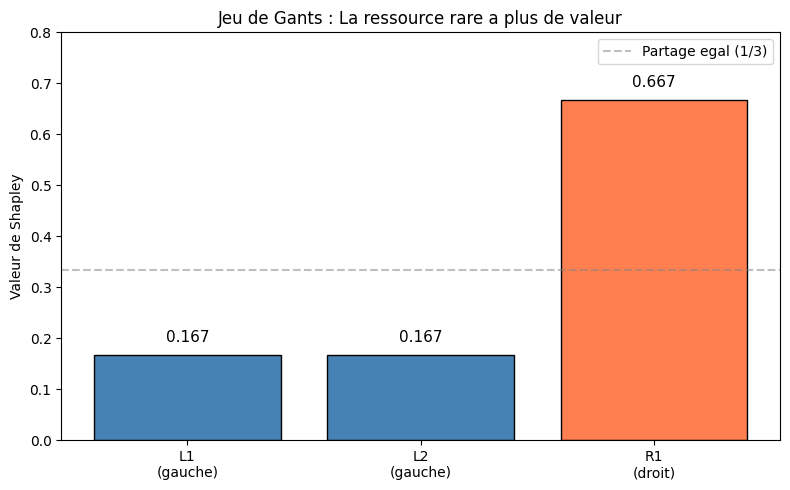

In [5]:
# Visualisation
fig, ax = plt.subplots(figsize=(8, 5))

players = ['L1\n(gauche)', 'L2\n(gauche)', 'R1\n(droit)']
colors = ['steelblue', 'steelblue', 'coral']

bars = ax.bar(players, shapley_glove, color=colors, edgecolor='black')

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, shapley_glove):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{val:.3f}', ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Valeur de Shapley')
ax.set_title('Jeu de Gants : La ressource rare a plus de valeur')
ax.set_ylim(0, 0.8)
ax.axhline(y=1/3, color='gray', linestyle='--', alpha=0.5, label='Partage egal (1/3)')
ax.legend()

plt.tight_layout()
plt.show()

---

## 3. Core Vide : Jeu de Majorite

**Exercice 3 du notebook 21 Lean** : Montrer que le jeu de majorite simple a 3 joueurs a un Core vide.

In [6]:
def majority_game_3(coalition):
    """Jeu de majorite simple a 3 joueurs.
    v(S) = 1 si |S| >= 2, 0 sinon.
    """
    return 1 if len(coalition) >= 2 else 0

print("JEU DE MAJORITE SIMPLE A 3 JOUEURS")
print("=" * 50)

print("\nFonction caracteristique :")
for S in sorted(all_coalitions, key=lambda x: (len(x), tuple(sorted(x)))):
    coalition_str = '{' + ', '.join(str(i+1) for i in sorted(S)) + '}' if S else '{}'
    print(f"  v({coalition_str}) = {majority_game_3(S)}")

JEU DE MAJORITE SIMPLE A 3 JOUEURS

Fonction caracteristique :
  v({}) = 0
  v({1}) = 0
  v({2}) = 0
  v({3}) = 0
  v({1, 2}) = 1
  v({1, 3}) = 1
  v({2, 3}) = 1
  v({1, 2, 3}) = 1


### Interpretation : Structure du jeu de majorite

La fonction caracteristique revele une **symetrie parfaite** entre les joueurs :

- **Coalitions perdantes** (v=0) : singletons uniquement
- **Coalitions gagnantes** (v=1) : toute paire ou plus

Cette structure est celle d'un **jeu simple symetrique** : tous les joueurs sont interchangeables, et le resultat ne depend que de la taille de la coalition.

> **Propriete importante** : Dans ce jeu, chaque joueur est **critique** (pivotal) dans exactement 2 coalitions gagnantes minimales. Par exemple, le joueur 1 est critique dans {1,2} et {1,3}.

In [7]:
print("\nPREUVE QUE LE CORE EST VIDE")
print("=" * 50)
print("""
Pour qu'une allocation (x1, x2, x3) soit dans le Core :

1. Efficacite : x1 + x2 + x3 = v({1,2,3}) = 1

2. Stabilite (aucune coalition ne peut bloquer) :
   x1 + x2 >= v({1,2}) = 1
   x1 + x3 >= v({1,3}) = 1
   x2 + x3 >= v({2,3}) = 1

En additionnant les trois contraintes de stabilite :
   2(x1 + x2 + x3) >= 3
   2 * 1 >= 3   (par efficacite x1+x2+x3=1)
   2 >= 3       CONTRADICTION!

=> Le Core est VIDE.

Intuition : chaque coalition de 2 joueurs peut "bloquer" et demander
au moins 1, mais il n'y a que 1 a partager entre les 3 joueurs.
""")


PREUVE QUE LE CORE EST VIDE

Pour qu'une allocation (x1, x2, x3) soit dans le Core :

1. Efficacite : x1 + x2 + x3 = v({1,2,3}) = 1

2. Stabilite (aucune coalition ne peut bloquer) :
   x1 + x2 >= v({1,2}) = 1
   x1 + x3 >= v({1,3}) = 1
   x2 + x3 >= v({2,3}) = 1

En additionnant les trois contraintes de stabilite :
   2(x1 + x2 + x3) >= 3
   2 * 1 >= 3   (par efficacite x1+x2+x3=1)
   2 >= 3       CONTRADICTION!

=> Le Core est VIDE.

Intuition : chaque coalition de 2 joueurs peut "bloquer" et demander
au moins 1, mais il n'y a que 1 a partager entre les 3 joueurs.



### Interpretation : Preuve du Core vide

La preuve utilise une technique classique de **sommation des contraintes** :

1. **Contraintes individuelles** : Chaque paire de joueurs exige au moins 1 (car ils forment une coalition gagnante)
2. **Sommation** : En additionnant les 3 contraintes de paires, chaque joueur apparait 2 fois
3. **Contradiction** : On obtient 2 fois le total a distribuer >= 3, soit 2 >= 3

> **Consequence pratique** : Dans un jeu de majorite simple, aucun partage ne peut satisfaire toutes les coalitions. Toute proposition sera bloquee par une coalition de 2 joueurs qui peut obtenir plus en faisant secession.

Cette situation illustre le concept d'**instabilite coalitionnelle** : meme si la grande coalition est efficace, elle ne peut pas se former de maniere stable.

In [8]:
# Shapley du jeu de majorite (tous egaux)
shapley_majority = shapley_value_exact(majority_game_3, 3)

print("\nVALEURS DE SHAPLEY :")
for i, val in enumerate(shapley_majority):
    print(f"  Joueur {i+1}: {val:.4f} = 1/3")

print("\nNote : Shapley donne une allocation 'juste' (1/3, 1/3, 1/3)")
print("mais cette allocation n'est PAS stable (pas dans le Core).")
print("\nVerification : chaque coalition de 2 peut bloquer")
print(f"  x1 + x2 = {shapley_majority[0] + shapley_majority[1]:.4f} < 1 = v({{1,2}})")


VALEURS DE SHAPLEY :
  Joueur 1: 0.3333 = 1/3
  Joueur 2: 0.3333 = 1/3
  Joueur 3: 0.3333 = 1/3

Note : Shapley donne une allocation 'juste' (1/3, 1/3, 1/3)
mais cette allocation n'est PAS stable (pas dans le Core).

Verification : chaque coalition de 2 peut bloquer
  x1 + x2 = 0.6667 < 1 = v({1,2})


---

## 4. Jeux de Vote Ponderes et Banzhaf

Un jeu de vote pondere $[q; w_1, w_2, ..., w_n]$ ou une coalition gagne si $\sum_{i \in S} w_i \geq q$.

In [9]:
def weighted_voting_game(weights, quota):
    """Cree une fonction caracteristique pour un jeu de vote pondere."""
    def v(coalition):
        return 1 if sum(weights[i] for i in coalition) >= quota else 0
    return v

def banzhaf_index(v, n):
    """Calcule l'indice de Banzhaf (normalise).
    
    Compte le nombre de coalitions ou chaque joueur est critique.
    """
    critical_counts = [0] * n
    
    # Pour chaque coalition
    for r in range(1, n + 1):
        for S in combinations(range(n), r):
            S_set = frozenset(S)
            if v(S_set) == 1:  # Coalition gagnante
                for i in S:
                    # i est critique si S\{i} perd
                    S_minus_i = frozenset(j for j in S if j != i)
                    if v(S_minus_i) == 0:
                        critical_counts[i] += 1
    
    # Normaliser
    total = sum(critical_counts)
    if total == 0:
        return [0.0] * n
    return [c / total for c in critical_counts]

# Exemple : Conseil de securite de l'ONU simplifie [39; 7,7,7,7,7, 1,1,1,1,1]
# 5 membres permanents (poids 7), 10 non-permanents (poids 1)
# Simplification : [9; 7,7,1,1,1] (2 permanents, 3 non-permanents)
weights_un = [7, 7, 1, 1, 1]
quota_un = 9
v_un = weighted_voting_game(weights_un, quota_un)

print("JEU DE VOTE PONDERE : Mini-ONU")
print("=" * 50)
print(f"[{quota_un}; {', '.join(map(str, weights_un))}]")
print("P1, P2 = permanents (poids 7), N1, N2, N3 = non-permanents (poids 1)")

shapley_un = shapley_value_exact(v_un, 5)
banzhaf_un = banzhaf_index(v_un, 5)

print("\nComparaison Shapley vs Banzhaf :")
labels = ['P1', 'P2', 'N1', 'N2', 'N3']
print(f"{'Joueur':<10} {'Poids':<10} {'Shapley':<10} {'Banzhaf':<10}")
print("-" * 40)
for label, w, s, b in zip(labels, weights_un, shapley_un, banzhaf_un):
    print(f"{label:<10} {w:<10} {s:<10.4f} {b:<10.4f}")

JEU DE VOTE PONDERE : Mini-ONU
[9; 7, 7, 1, 1, 1]
P1, P2 = permanents (poids 7), N1, N2, N3 = non-permanents (poids 1)

Comparaison Shapley vs Banzhaf :
Joueur     Poids      Shapley    Banzhaf   
----------------------------------------
P1         7          0.3000     0.2857    
P2         7          0.3000     0.2857    
N1         1          0.1333     0.1429    
N2         1          0.1333     0.1429    
N3         1          0.1333     0.1429    


### Interpretation : Indices de pouvoir

Les resultats revelent un **paradoxe classique de la theorie du vote** :

| Joueur | Poids nominal | Pouvoir reel (Shapley) | Ratio pouvoir/poids |
|--------|---------------|------------------------|---------------------|
| P1, P2 | 7 (41%) | 0.30 (30%) | 0.73 |
| N1-N3 | 1 (6%) | 0.13 (13%) | 2.17 |

**Observations cles** :

1. **Les permanents ont moins de pouvoir que leur poids suggere** : avec 41% du poids, ils n'ont que 30% du pouvoir
2. **Les non-permanents ont plus de pouvoir relatif** : leur pouvoir (13%) depasse leur poids (6%)
3. **Shapley vs Banzhaf** : les deux indices sont proches ici, mais Shapley donne legerement plus de poids aux permanents

> **Application pratique** : Dans le vrai Conseil de Securite de l'ONU, le droit de veto des permanents leur confere un pouvoir absolu (indice = 1 si veto, 0 sinon pour certaines decisions).

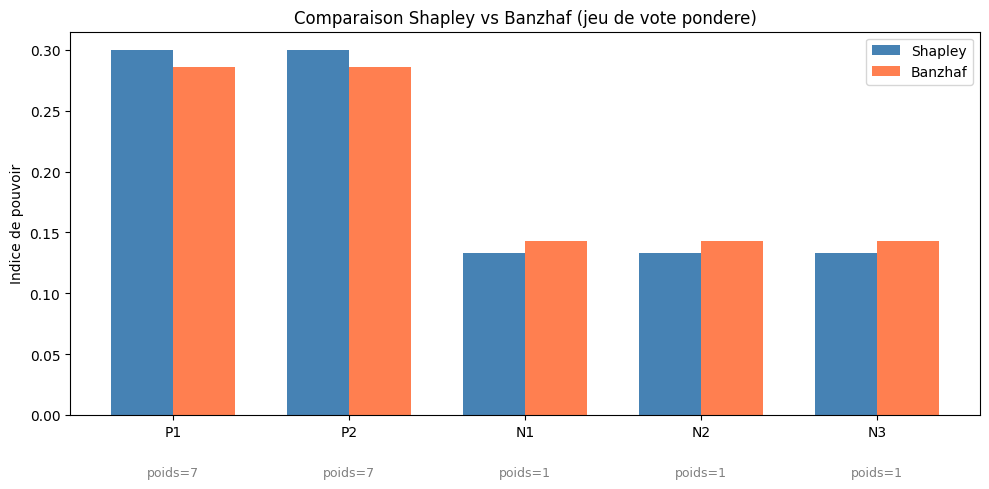

Note : Le pouvoir reel (Shapley/Banzhaf) peut differer du poids nominal!


In [10]:
# Visualisation comparative
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(labels))
width = 0.35

bars1 = ax.bar(x - width/2, shapley_un, width, label='Shapley', color='steelblue')
bars2 = ax.bar(x + width/2, banzhaf_un, width, label='Banzhaf', color='coral')

ax.set_ylabel('Indice de pouvoir')
ax.set_title('Comparaison Shapley vs Banzhaf (jeu de vote pondere)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Ajouter les poids en annotation
for i, w in enumerate(weights_un):
    ax.annotate(f'poids={w}', xy=(i, 0), xytext=(i, -0.05),
                ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

print("Note : Le pouvoir reel (Shapley/Banzhaf) peut differer du poids nominal!")

---

## 5. Jeux Convexes : Shapley dans le Core

Un jeu est **convexe** (supermodulaire) si les contributions marginales sont croissantes. Pour les jeux convexes, la valeur de Shapley est dans le Core.

In [11]:
def is_convex(v, n):
    """Verifie si un jeu est convexe.
    
    Un jeu est convexe si pour tout S, T : v(S) + v(T) <= v(S u T) + v(S n T)
    """
    for r1 in range(n + 1):
        for S in combinations(range(n), r1):
            S = frozenset(S)
            for r2 in range(n + 1):
                for T in combinations(range(n), r2):
                    T = frozenset(T)
                    lhs = v(S) + v(T)
                    rhs = v(S | T) + v(S & T)
                    if lhs > rhs + 1e-10:  # Tolerance numerique
                        return False
    return True

# Test sur le jeu de gants
print("TEST DE CONVEXITE")
print("=" * 40)
print(f"Jeu de gants convexe ? {is_convex(glove_game, 3)}")
print(f"Jeu de majorite convexe ? {is_convex(majority_game_3, 3)}")

# Jeu d'unanimite (toujours convexe)
def unanimity_game(T):
    """Jeu d'unanimite : v(S) = 1 si T inclus dans S, 0 sinon."""
    def v(coalition):
        return 1 if T <= coalition else 0
    return v

v_unan = unanimity_game(frozenset({0, 1}))
print(f"Jeu d'unanimite u_{{1,2}} convexe ? {is_convex(v_unan, 3)}")

TEST DE CONVEXITE
Jeu de gants convexe ? False
Jeu de majorite convexe ? False
Jeu d'unanimite u_{1,2} convexe ? True


### Interpretation : Tests de convexite

Les resultats revelent une propriete fondamentale des jeux cooperatifs :

| Jeu | Convexe ? | Explication |
|-----|-----------|-------------|
| **Gants** | Non | Le joueur R1 (ressource rare) a des rendements decroissants quand il rejoint de grandes coalitions |
| **Majorite** | Non | Deux joueurs quelconques suffisent pour gagner - pas de synergie supplementaire |
| **Unanimite** | Oui | Les contributions marginales sont nulles sauf pour les coalitions contenant T |

> **Intuition economique** : Un jeu est convexe lorsque "plus on est nombreux, plus chaque nouvel arrivant apporte de valeur". C'est le cas des jeux avec fortes complementarites entre joueurs.

In [12]:
# Verification que Shapley est dans le Core pour un jeu convexe
def is_in_core(allocation, v, n):
    """Verifie si une allocation est dans le Core."""
    # Efficacite
    if abs(sum(allocation) - v(frozenset(range(n)))) > 1e-10:
        return False, "Pas efficace"
    
    # Stabilite
    for r in range(1, n):
        for S in combinations(range(n), r):
            S_set = frozenset(S)
            coalition_value = sum(allocation[i] for i in S)
            if coalition_value < v(S_set) - 1e-10:
                return False, f"Coalition {S} peut bloquer"
    
    return True, "Dans le Core"

# Jeu convexe simple
def convex_game(coalition):
    """Un jeu convexe : v(S) = |S|^2 / 9."""
    return len(coalition) ** 2 / 9

print("\nJEU CONVEXE : v(S) = |S|^2 / 9")
print("=" * 40)
print(f"Convexe ? {is_convex(convex_game, 3)}")

shapley_convex = shapley_value_exact(convex_game, 3)
print(f"\nShapley : {shapley_convex}")

in_core, msg = is_in_core(shapley_convex, convex_game, 3)
print(f"Shapley dans le Core ? {in_core} - {msg}")

# Verification du jeu de majorite (non convexe, Shapley hors Core)
print(f"\nJeu de majorite :")
in_core_maj, msg_maj = is_in_core(shapley_majority, majority_game_3, 3)
print(f"Shapley dans le Core ? {in_core_maj} - {msg_maj}")


JEU CONVEXE : v(S) = |S|^2 / 9
Convexe ? True

Shapley : [0.3333333333333333, 0.3333333333333333, 0.3333333333333333]
Shapley dans le Core ? True - Dans le Core

Jeu de majorite :
Shapley dans le Core ? False - Coalition (0, 1) peut bloquer


---

## Resume

| Concept | Implementation Python |
|---------|----------------------|
| Shapley exact | `shapley_value_exact(v, n)` |
| Banzhaf | `banzhaf_index(v, n)` |
| Vote pondere | `weighted_voting_game(weights, quota)` |
| Test convexite | `is_convex(v, n)` |
| Test Core | `is_in_core(allocation, v, n)` |

**Lien avec le notebook 21 Lean** :

| Notebook 21 (Lean) | Notebook 21b (Python) |
|--------------------|----------------------|
| Axiomes de Shapley | Calcul numerique |
| Theoreme d'unicite | Verification empirique |
| Definition du Core | Test d'appartenance |
| Jeux de vote | Banzhaf et comparaison |

---

**Navigation** : [← GameTheory-15b-Lean-CooperativeGames](GameTheory-15b-Lean-CooperativeGames.ipynb) | [Index](GameTheory-1-Setup.ipynb) | [Fin de la serie]

---

## 13. Exemples guides

### Exemple guide 1 : Jeu de l'aeroport

Trois compagnies aeriennes partagent un aeroport. Les couts de construction selon les coalitions (en M€) sont :
- v({A})=10, v({B})=20, v({C})=30
- v({A,B})=25, v({A,C})=35, v({B,C})=40, v({A,B,C})=50

Calculez la valeur de Shapley pour chaque compagnie.

### Exemple guide 2 : Jeu de majorite politique

Quatre partis (A=40%, B=30%, C=20%, D=10%) doivent former une coalition majoritaire (>50%). Calculez les indices de Banzhaf pour determiner le pouvoir de vote reel.

### Exemple guide 3 : Jeu de fusion d'entreprises

Trois entreprises ont des valeurs solo (v({1})=100, v({2})=150, v({3})=200). En fusion elles valent v({1,2})=350, v({1,3})=400, v({2,3})=450, v({1,2,3})=700. Le Core est-il non-vide ? Calculez Shapley et verifiez s'il appartient au Core.

In [13]:
# Espace pour les exercices

# Exemple guide 1 : Jeu de l'aeroport
def airport_value(coalition):
    # TODO etudiant : definir la fonction caracteristique
    return None  # TODO etudiant : remplacer par les valeurs

# TODO etudiant : calculer shapley_value_exact(airport_value, 3)

# Exemple guide 2 : Partis politiques
def political_game(coalition):
    # TODO etudiant : renvoyer 1 si la coalition est majoritaire (>50%), 0 sinon
    weights = {0: 40, 1: 30, 2: 20, 3: 10}  # poids en %
    return None  # TODO etudiant

# TODO etudiant : calculer banzhaf_index(political_game, 4)

# Exemple guide 3 : Fusion d'entreprises
def merger_value(coalition):
    # TODO etudiant : definir les valeurs de coalition
    return None  # TODO etudiant

# TODO etudiant : is_convex(merger_value, 3), core, shapley

print("Exercice a completer")

Exercice a completer


---

**Notebook precedent**: [GameTheory-15b-Lean-CooperativeGames](../GameTheory-15b-Lean-CooperativeGames.ipynb)  
**Notebook suivant**: [GameTheory-16-MechanismDesign](../GameTheory-16-MechanismDesign.ipynb)